Imports

In [1]:
#data importing and manipulation

import pandas as pd
import numpy as np
#For visualization
import matplotlib.pyplot as plt

#text preprocessing
import re
import string
import emoji

#To save the models
import joblib

#spliting data

from sklearn.model_selection import train_test_split, cross_val_score

#vectorization and encoding

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

#importing models 
from sklearn.linear_model import LogisticRegression #for Logistic Regression(Model 1)
from sklearn.svm import LinearSVC #for linear SVC(Model 2)
from sklearn.ensemble import RandomForestClassifier #for Random Forest(Model 3)
from sklearn.naive_bayes import MultinomialNB #for Naive Bayes(Model 4)

#evaluation metrics

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#for hyperparameter tuning

from scipy.sparse import hstack
#for GRU(Model 5)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping


c:\Users\kuike\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Data Loading

In [ ]:
df = pd.read_csv("D:\\AI\\Final_Assignment\\data\\dataset.csv")
df.head()


,Review Id,Review,Ratings,Review Date,Sentiment
0,e23e7629-89a4-40b8-9c03-3c91dff7130b,good 👍,4,1/16/2024 14:11,Positive
1,fbdd298c-d4dc-471b-ab5a-1724559dc8b8,nice,5,6/12/2024 13:13,Positive
2,34488a06-6649-4018-983b-d7f624440b83,Doesn help me,1,6/5/2024 8:18,Negative
3,8edd27dd-284a-4514-9afa-82c083b82cdb,works well just sometimes can't understand wha...,4,8/21/2023 11:17,Positive
4,3b1c7517-5c6d-46d3-89ae-8ddb943e3a05,it doesn't understand,3,4/26/2024 11:47,Neutral


Basic data cleaning

In [3]:
df.dropna(inplace=True) # Remove rows with missing values
df.drop_duplicates(subset='Review', inplace=True) # Remove duplicate reviews based on the 'Review' column

print("Dataset Shape:", df.shape)
print(df['Sentiment'].value_counts()) # Check class distribution

Dataset Shape: (37458, 5)
Sentiment
Positive    18104
Negative    13190
Neutral      6164
Name: count, dtype: int64


Preprocessing

In [4]:
def clean_text(text):
    text = str(text).lower()
    
    # Convert emoji to descriptive text
    text = emoji.demojize(text)
    
    # Replace underscore with space (important improvement)
    text = text.replace("_", " ")
    
    # Remove URLs
    text = re.sub(r"http\S+", "", text)
    
    # Remove numbers
    text = re.sub(r"\d+", "", text)
    
    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text


In [5]:
df['clean_review'] = df['Review'].apply(clean_text)
df.head()

,Review Id,Review,Ratings,Review Date,Sentiment,clean_review
0,e23e7629-89a4-40b8-9c03-3c91dff7130b,good 👍,4,1/16/2024 14:11,Positive,good thumbs up
1,fbdd298c-d4dc-471b-ab5a-1724559dc8b8,nice,5,6/12/2024 13:13,Positive,nice
2,34488a06-6649-4018-983b-d7f624440b83,Doesn help me,1,6/5/2024 8:18,Negative,doesn help me
3,8edd27dd-284a-4514-9afa-82c083b82cdb,works well just sometimes can't understand wha...,4,8/21/2023 11:17,Positive,works well just sometimes cant understand what...
4,3b1c7517-5c6d-46d3-89ae-8ddb943e3a05,it doesn't understand,3,4/26/2024 11:47,Neutral,it doesnt understand


Spliting the dataset

In [6]:
X_text = df['clean_review']
y = df['Sentiment']

X_train_text, X_test_text, y_train, y_test = train_test_split(X_text,y,test_size=0.2,random_state=42,stratify=y)


Vectorizing

In [7]:

tfidf_vectorizer = TfidfVectorizer(max_features=5000,ngram_range=(1, 2),min_df=2,stop_words='english')

X_train = tfidf_vectorizer.fit_transform(X_train_text)
X_test = tfidf_vectorizer.transform(X_test_text)



Label encoder

In [8]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)


Machine learning Models

In [9]:
results = {}

Logistic Regression (Model 1)

In [10]:

lr = LogisticRegression(max_iter=1000) #Initialize Logistic Regression with increased max_iter to ensure convergence
lr.fit(X_train, y_train_enc) #Train Logistic Regression on the training data
y_pred_lr = lr.predict(X_test) #Predict using Logistic Regression on the test data


In [11]:
#Evaluation
results['Logistic Regression'] = accuracy_score(y_test_enc, y_pred_lr) #Store Logistic Regression accuracy in results dictionary
print(f"\nLogistic Regression Accuracy: {results['Logistic Regression']*100:.2f}%")#Print Logistic Regression accuracy in percentage format with 2 decimal places
print("\nLogistic Regression Report")
print(classification_report(y_test_enc, y_pred_lr))#Print classification report for Logistic Regression predictions


Logistic Regression Accuracy: 69.11%

Logistic Regression Report
              precision    recall  f1-score   support

           0       0.71      0.73      0.72      2638
           1       0.32      0.08      0.13      1233
           2       0.70      0.87      0.78      3621

    accuracy                           0.69      7492
   macro avg       0.58      0.56      0.54      7492
weighted avg       0.64      0.69      0.65      7492



SVM (Model 2)

In [12]:
svm = LinearSVC() #Initialize LinearSVC model
svm.fit(X_train, y_train_enc) #Train LinearSVC on the training data
y_pred_svm = svm.predict(X_test) #Predict using LinearSVC on the test data

In [13]:
#Evaluation
results['SVM'] = accuracy_score(y_test_enc, y_pred_svm) #Store SVM accuracy in results dictionary
print(f"\nSVM Accuracy: {results['SVM']*100:.2f}%") #Print SVM accuracy in percentage format with 2 decimal places
print("\nSVM Report")
print(classification_report(y_test_enc, y_pred_svm)) #Print classification report for SVM predictions



SVM Accuracy: 67.34%

SVM Report
              precision    recall  f1-score   support

           0       0.70      0.69      0.70      2638
           1       0.28      0.10      0.15      1233
           2       0.70      0.85      0.77      3621

    accuracy                           0.67      7492
   macro avg       0.56      0.55      0.54      7492
weighted avg       0.63      0.67      0.64      7492



Random forest (Model 3)

In [14]:
rf = RandomForestClassifier(n_estimators=200, random_state=42) #Initialize Random Forest with 200 trees and a fixed random state for reproducibility
rf.fit(X_train.toarray(), y_train_enc) #Train Random Forest on the training data (convert sparse matrix to dense array for compatibility)
y_pred_rf = rf.predict(X_test.toarray()) #Predict using Random Forest on the test data (convert sparse matrix to dense array for compatibility)

In [15]:
#Evaluation
results['Random Forest'] = accuracy_score(y_test_enc, y_pred_rf) #Store Random Forest accuracy in results dictionary
print(f"\nRandom Forest Accuracy: {results['Random Forest']*100:.2f}%") #Print Random Forest accuracy in percentage format with 2 decimal places
print("\nRandom Forest Report")
print(classification_report(y_test_enc, y_pred_rf)) #Print classification report for Random Forest predictions


Random Forest Accuracy: 67.18%

Random Forest Report
              precision    recall  f1-score   support

           0       0.68      0.71      0.69      2638
           1       0.29      0.05      0.09      1233
           2       0.68      0.86      0.76      3621

    accuracy                           0.67      7492
   macro avg       0.55      0.54      0.51      7492
weighted avg       0.62      0.67      0.63      7492



Multinomial Naive Bayes (Model 5)

In [18]:
nb = MultinomialNB() #initialize Multinomial Naive Bayes model
nb.fit(X_train, y_train_enc) #Train Multinomial Naive Bayes on the training data
y_pred_nb = nb.predict(X_test) #Predict using Multinomial Naive Bayes on the test data

In [19]:
#Evaluation
results['MultinomialNB'] = accuracy_score(y_test_enc, y_pred_nb) #Store Multinomial Naive Bayes accuracy in results dictionary
print(f"\nMultinomialNB Accuracy: {results['MultinomialNB']*100:.2f}%") #Print Multinomial Naive Bayes accuracy in percentage format with 2 decimal places
print("\nMultinomialNB Report") 
print(classification_report(y_test_enc, y_pred_nb)) #Print classification report for Multinomial Naive Bayes predictions


MultinomialNB Accuracy: 68.91%

MultinomialNB Report
              precision    recall  f1-score   support

           0       0.70      0.73      0.71      2638
           1       0.33      0.04      0.07      1233
           2       0.69      0.88      0.78      3621

    accuracy                           0.69      7492
   macro avg       0.57      0.55      0.52      7492
weighted avg       0.64      0.69      0.64      7492



GRU MODEL (Model 5)

In [20]:
# Limit vocabulary size and sequence length for GRU model
max_words = 10000
max_len = 100

In [21]:
# Tokenization
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)


In [22]:
# Model 
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(GRU(64))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(len(le.classes_), activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])


early_stop = EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)

history = model.fit(X_train_pad,y_train_enc,validation_split=0.2,epochs=15,batch_size=32,callbacks=[early_stop])


c:\Users\kuike\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 32s 39ms/step - accuracy: 0.6508 - loss: 0.8474 - val_accuracy: 0.7059 - val_loss: 0.7325
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - accuracy: 0.7265 - loss: 0.6988 - val_accuracy: 0.7067 - val_loss: 0.7313
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step - accuracy: 0.7577 - loss: 0.6224 - val_accuracy: 0.6992 - val_loss: 0.7831
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - accuracy: 0.7827 - loss: 0.5603 - val_accuracy: 0.6815 - val_loss: 0.8225
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - accuracy: 0.8037 - loss: 0.5088 - val_accuracy: 0.6795 - val_loss: 0.8892


In [23]:
# Evaluation
loss, acc = model.evaluate(X_test_pad, y_test_enc)
results['GRU'] = acc

print("\nGRU Accuracy:", acc)


235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7109 - loss: 0.7238

GRU Accuracy: 0.710891604423523


Comparison

In [24]:
comparison_df = pd.DataFrame(results.items(), columns=['Model', 'Accuracy'])
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False)

print("\nFinal Model Comparison")
print(comparison_df)



Final Model Comparison
                 Model  Accuracy
4                  GRU  0.710892
0  Logistic Regression  0.691137
3        MultinomialNB  0.689135
1                  SVM  0.673385
2        Random Forest  0.671783


Visualization

In [25]:
#Data Manipulation for visualization
# Convert dictionary to DataFrame
comparison_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])

# Sort by accuracy (optional but recommended)
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False)

# Prepare data for heatmap
heatmap_data = comparison_df.set_index('Model')


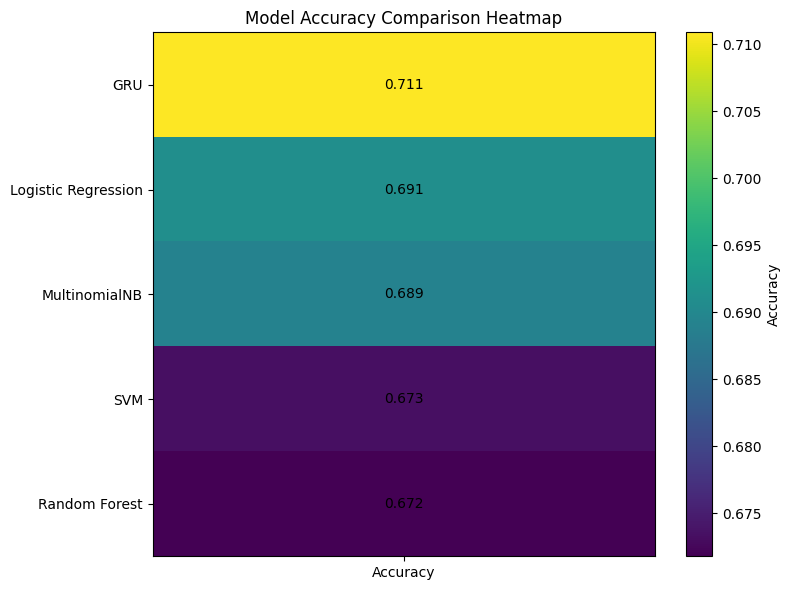

In [26]:
#create heatmap 
# Create figure
plt.figure(figsize=(8, 6))

# Create heatmap using matplotlib
plt.imshow(heatmap_data, aspect='auto')

# Add color bar
plt.colorbar(label='Accuracy')

# Set labels
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.xticks([0], ['Accuracy'])

# Add accuracy values inside cells
for i, value in enumerate(heatmap_data['Accuracy']):
    plt.text(0, i, f"{value:.3f}", ha='center', va='center', color='black')

# Title
plt.title('Model Accuracy Comparison Heatmap')

plt.tight_layout()
plt.show()

Saving all the models

In [ ]:

# Save Machine Learning Models
joblib.dump(lr, "D:\\AI\\Final_Assignment\\models\\logistic_regression.pkl")
joblib.dump(svm, "D:\\AI\\Final_Assignment\\models\\svm.pkl")
joblib.dump(rf, "D:\\AI\\Final_Assignment\\models\\random_forest.pkl")
joblib.dump(nb, "D:\\AI\\Final_Assignment\\models\\multinomial_nb.pkl")


['D:\\AI\\final assignment\\models\\multinomial_nb.pkl']

In [ ]:

# Save TF-IDF Vectorizer
joblib.dump(tfidf_vectorizer, "D:\\AI\\Final_Assignment\\models\\tfidf_vectorizer.pkl")
# Save Label Encoder
joblib.dump(le, "D:\\AI\\Final_Assignment\\models\\label_encoder.pkl")
# Save Tokenizer (Required for GRU)
joblib.dump(tokenizer, "D:\\AI\\Final_Assignment\\models\\tokenizer.pkl")

['D:\\AI\\final assignment\\models\\tokenizer.pkl']

In [ ]:
# Save GRU Model
model.save("D:\\AI\\Final_Assignment\\models\\gru_model.h5")
model.save('D:\\AI\\Final_Assignment\\models\\my_model.keras')